In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12, 'figure.figsize': (10, 6)})

import sys
import os
sys.path.append(os.path.abspath('..'))
from ab_framework.data.generator import FintechDataGenerator

In [ ]:
generator = FintechDataGenerator(
    n_users=100000, 
    whale_frac=0.05, 
    effect_size=0.0, 
    correlation_noise=0.15
)

# Генерация
df = generator.generate_dataset(seed=42)
print(f"Размер датасета: {df.shape}")
display(df.head())

Размер датасета: (100000, 6)


,user_id,device_type,age_group,is_treated,pre_experiment_metric,target_metric
0,1,iOS,25-34,0,287.98,336.75
1,2,Web,25-34,0,760.56,655.68
2,3,Android,25-34,0,171.39,184.92
3,4,Android,25-34,0,331.71,395.35
4,5,iOS,25-34,0,1120.65,1094.57


In [24]:
target = df['target_metric']

print(" Статистика целевой метрики")
print(f"Среднее (Mean):      {target.mean():.2f}")
print(f"Медиана (Median):    {target.median():.2f}")
print(f"Максимум (Max):      {target.max():.2f}")
print(f"99-й перцентиль:     {np.percentile(target, 99):.2f}")
print(f"Станд. отклонение:   {target.std():.2f}")

from scipy.stats import skew, kurtosis
print(f"\nАсимметрия (Skewness): {skew(target):.2f} (Сильно > 0, хвост вправо)")
print(f"Эксцесс (Kurtosis):    {kurtosis(target):.2f} (Сильно > 3, тяжелые хвосты)")

 Статистика целевой метрики
Среднее (Mean):      925.23
Медиана (Median):    425.83
Максимум (Max):      2044654.93
99-й перцентиль:     6301.50
Станд. отклонение:   9961.66

Асимметрия (Skewness): 124.37 (Сильно > 0, хвост вправо)
Эксцесс (Kurtosis):    20879.49 (Сильно > 3, тяжелые хвосты)


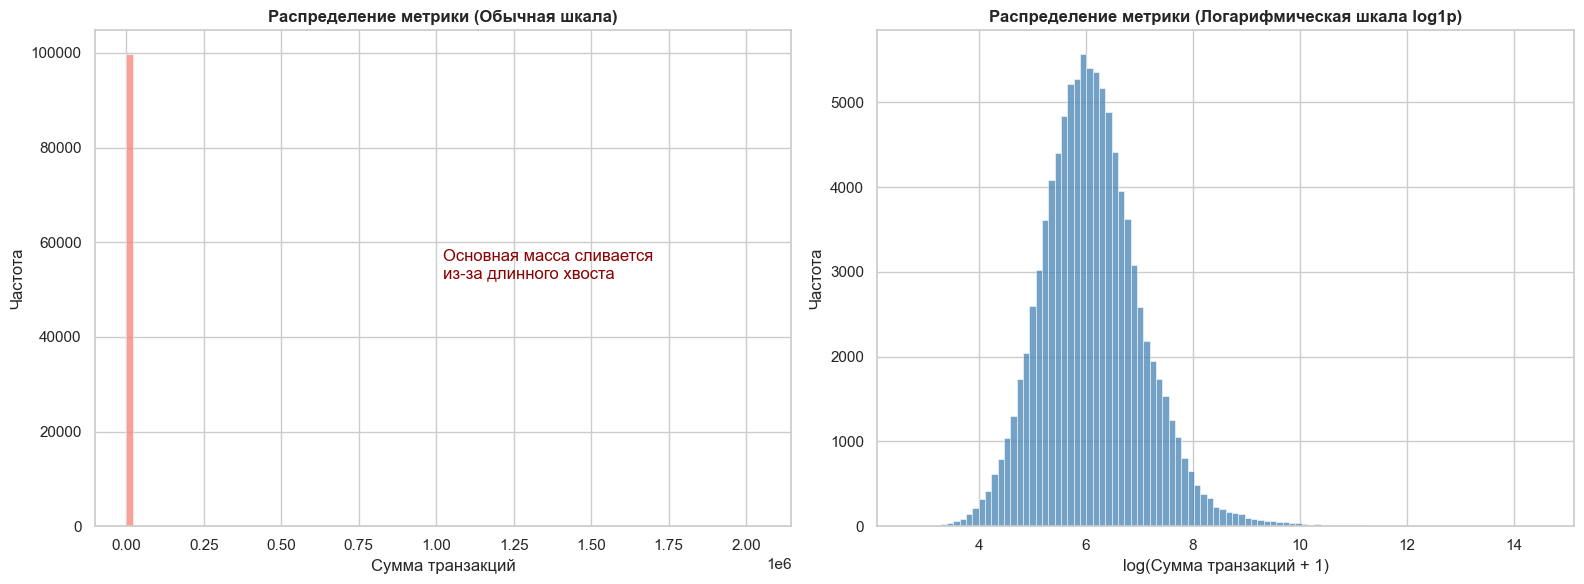

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(target, bins=100, ax=axes[0], color='salmon')
axes[0].set_title('Распределение метрики (Обычная шкала)', fontweight='bold')
axes[0].set_xlabel('Сумма транзакций')
axes[0].set_ylabel('Частота')
axes[0].text(0.5, 0.5, 'Основная масса сливается\nиз-за длинного хвоста', 
             transform=axes[0].transAxes, fontsize=12, color='darkred')

sns.histplot(np.log1p(target), bins=100, ax=axes[1], color='steelblue')
axes[1].set_title('Распределение метрики (Логарифмическая шкала log1p)', fontweight='bold')
axes[1].set_xlabel('log(Сумма транзакций + 1)')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

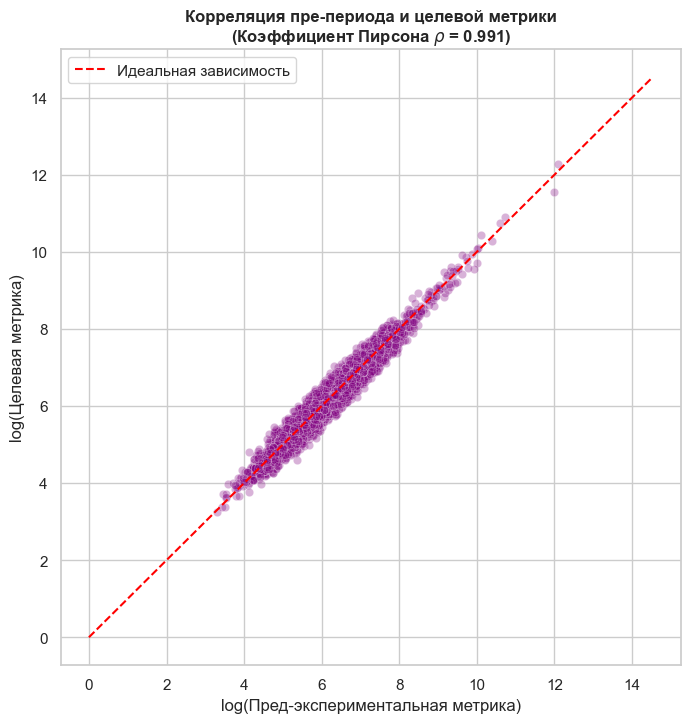

In [ ]:
plt.figure(figsize=(8, 8))

df_sample = df.sample(5000, random_state=42)

sns.scatterplot(
    x=np.log1p(df_sample['pre_experiment_metric']), 
    y=np.log1p(df_sample['target_metric']), 
    alpha=0.3, 
    color='purple'
)

rho = df['pre_experiment_metric'].corr(df['target_metric'])

plt.title(f'Корреляция пре-периода и целевой метрики\n(Коэффициент Пирсона $\\rho$ = {rho:.3f})', fontweight='bold')
plt.xlabel('log(Пред-экспериментальная метрика)')
plt.ylabel('log(Целевая метрика)')

max_val = np.log1p(df['target_metric'].max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Идеальная зависимость')
plt.legend()
plt.show()

---
## Часть 2: EDA новых сценариев бенчмарка

Визуализация четырёх сценариев, используемых в Monte Carlo бенчмарке. Каждый сценарий создан для демонстрации конкретного случая применения метода.

In [17]:
from ab_framework.data.generator import (
    EcommerceScenario, LowCorrelationScenario, RatioScenario, SegmentedScenario
)

N = 10_000
sc_ecomm  = EcommerceScenario().generate              (N, 0.0, seed=42)
sc_lowcor = LowCorrelationScenario().generate           (N, 0.0, seed=42)
sc_ratio  = RatioScenario().generate(N, 0.0, seed=42)
sc_seg    = SegmentedScenario().generate(N, 0.0, seed=42)

print('EcommerceScenario:     ', sc_ecomm.shape,  list(sc_ecomm.columns))
print('LowCorrelationScenario:', sc_lowcor.shape, list(sc_lowcor.columns))
print('RatioScenario:         ', sc_ratio.shape,  list(sc_ratio.columns))
print('SegmentedScenario:     ', sc_seg.shape,    list(sc_seg.columns))


EcommerceScenario:      (10000, 6) ['user_id', 'group', 'pre_revenue', 'revenue', 'device_type', 'age_group']
LowCorrelationScenario: (10000, 6) ['user_id', 'group', 'pre_revenue', 'revenue', 'device_type', 'age_group']
RatioScenario:          (10000, 5) ['user_id', 'group', 'revenue', 'n_sessions', 'device_type']
SegmentedScenario:      (10000, 4) ['user_id', 'group', 'revenue', 'device_type']


### 2.1 Распределение метрики revenue по сценариям

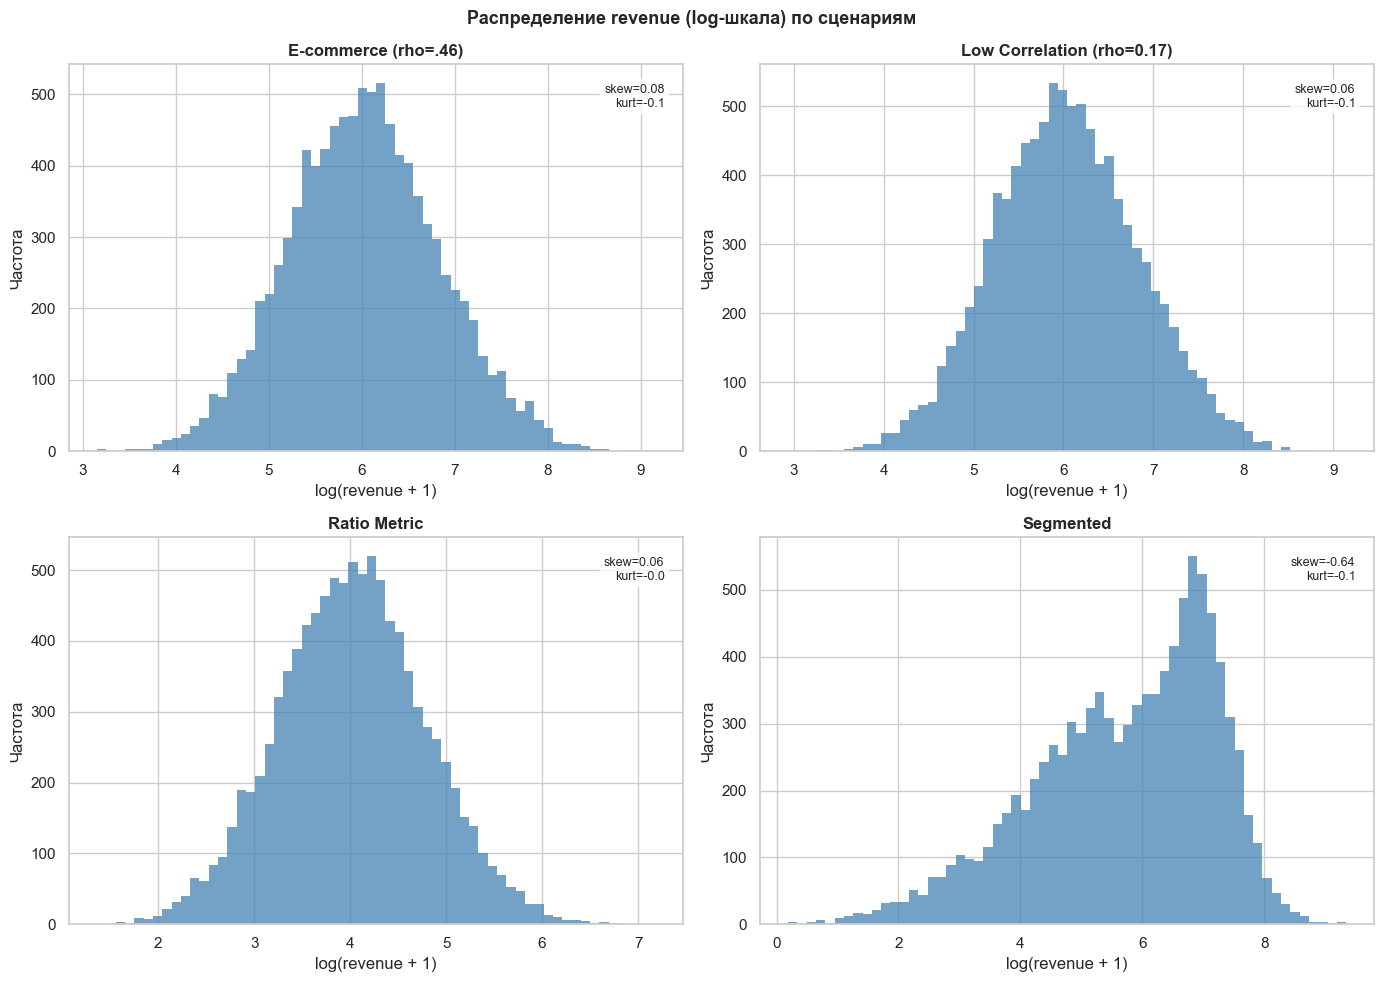

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
datasets = [
    (sc_ecomm,  'E-commerce (rho=.46)',    axes[0,0]),
    (sc_lowcor, 'Low Correlation (rho=0.17)', axes[0,1]),
    (sc_ratio,  'Ratio Metric',              axes[1,0]),
    (sc_seg,    'Segmented',                 axes[1,1]),
]

for df_s, title, ax in datasets:
    x = np.log1p(df_s['revenue'])
    ax.hist(x, bins=60, color='steelblue', alpha=0.75, edgecolor='none')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('log(revenue + 1)')
    ax.set_ylabel('Частота')
    mu, sigma = x.mean(), x.std()
    skewness = float(((x - mu)**3).mean() / sigma**3)
    kurt = float(((x - mu)**4).mean() / sigma**4) - 3
    ax.text(0.97, 0.95, f'skew={skewness:.2f}\nkurt={kurt:.1f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Распределение revenue (log-шкала) по сценариям', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


### 2.2 Корреляция pre/post — ключевой параметр для CUPED

Сравниваем `EcommerceScenario` (rho=0.46) и `LowCorrelationScenario` (rho=0.17). Видно почему CUPED эффективен только в первом случае.

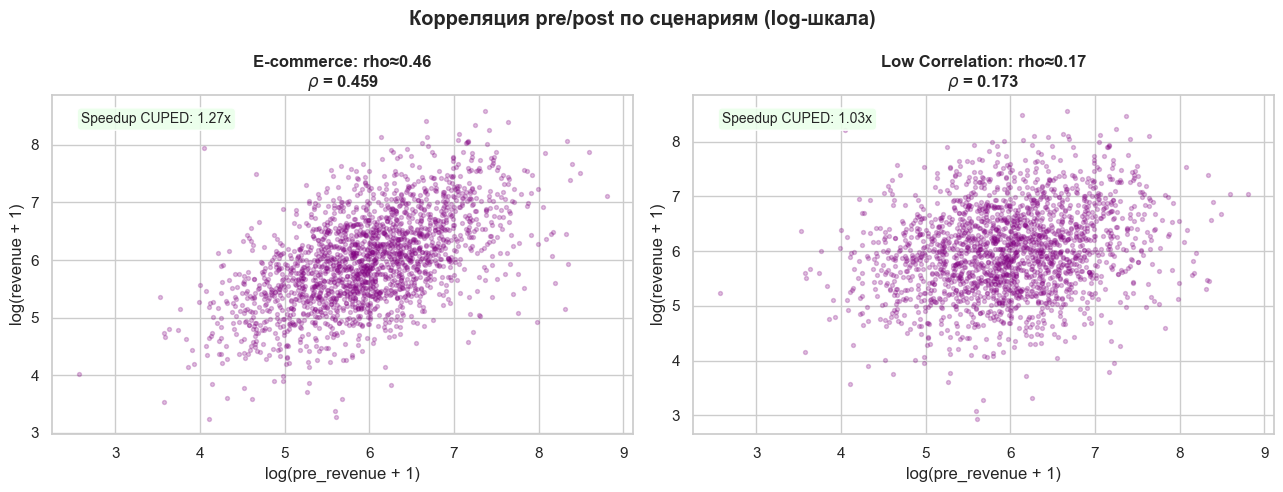

EcommerceScenario:      rho = 0.459
LowCorrelationScenario: rho = 0.173


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for df_s, title, ax in [
    (sc_ecomm,  'E-commerce: rho=0.46',        axes[0]),
    (sc_lowcor, 'Low Correlation: rho=0.17',  axes[1]),
]:
    sample = df_s.sample(2000, random_state=42)
    rho = df_s['pre_revenue'].corr(df_s['revenue'])
    ax.scatter(np.log1p(sample['pre_revenue']), np.log1p(sample['revenue']),
               alpha=0.25, s=8, color='purple')
    ax.set_title(f'{title}\n$\\rho$ = {rho:.3f}', fontweight='bold')
    ax.set_xlabel('log(pre_revenue + 1)')
    ax.set_ylabel('log(revenue + 1)')
    speedup = 1 / (1 - rho**2)
    ax.text(0.05, 0.95, f'Speedup CUPED: {speedup:.2f}x',
            transform=ax.transAxes, va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='#eaffea', alpha=0.9))

plt.suptitle('Корреляция pre/post по сценариям (log-шкала)', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'EcommerceScenario:      rho = {sc_ecomm["pre_revenue"].corr(sc_ecomm["revenue"]):.3f}')
print(f'LowCorrelationScenario: rho = {sc_lowcor["pre_revenue"].corr(sc_lowcor["revenue"]):.3f}')


### 2.3 Сегментированный сценарий — between-group variance

iOS / Android / Web имеют разные средние и дисперсии дохода. Именно это делает пост-стратификацию выгодной.

/var/folders/y2/khyv_p956cgc_hm8pjzdjn_80000gn/T/ipykernel_15186/1482871118.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sc_seg_log, x='device_type', y='log_revenue',


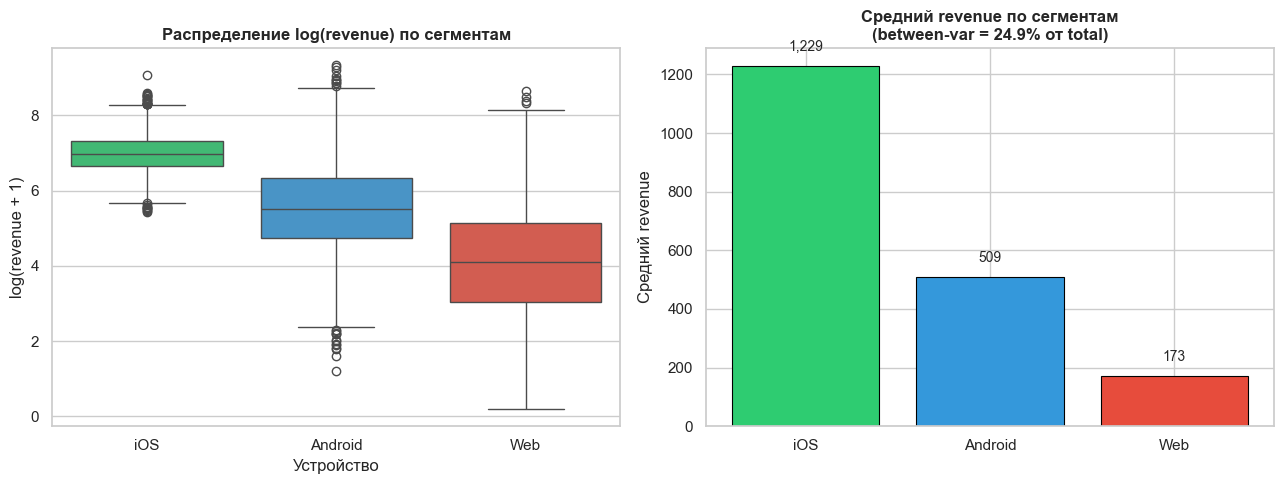

Between-group variance / Total variance = 0.249
is_stratification_beneficial = True


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

order = ['iOS', 'Android', 'Web']
palette = {'iOS': '#2ecc71', 'Android': '#3498db', 'Web': '#e74c3c'}
sc_seg_log = sc_seg.copy()
sc_seg_log['log_revenue'] = np.log1p(sc_seg_log['revenue'])

sns.boxplot(data=sc_seg_log, x='device_type', y='log_revenue',
            order=order, palette=palette, ax=axes[0])
axes[0].set_title('Распределение log(revenue) по сегментам', fontweight='bold')
axes[0].set_xlabel('Устройство')
axes[0].set_ylabel('log(revenue + 1)')

total_var = sc_seg['revenue'].var(ddof=1)
global_mean = sc_seg['revenue'].mean()
seg_stats = sc_seg.groupby('device_type')['revenue'].agg(['mean','count'])
between_var = sum(
    (cnt / len(sc_seg)) * (mn - global_mean)**2
    for mn, cnt in zip(seg_stats['mean'], seg_stats['count'])
)
btw_frac = between_var / total_var

seg_means = sc_seg.groupby('device_type')['revenue'].mean().reindex(order)
bars = axes[1].bar(order, seg_means, color=[palette[d] for d in order],
                   edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, seg_means):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+50,
                 f'{val:,.0f}', ha='center', fontsize=10)
axes[1].set_title(f'Средний revenue по сегментам\n(between-var = {btw_frac:.1%} от total)',
                  fontweight='bold')
axes[1].set_ylabel('Средний revenue')

plt.tight_layout()
plt.show()
print(f'Between-group variance / Total variance = {btw_frac:.3f}')
print(f'is_stratification_beneficial = {btw_frac > 0.10}')


### 2.4 Ratio Metric — ARPU = revenue / n_sessions

Показываем распределение ARPU и зависимость revenue от числа сессий.

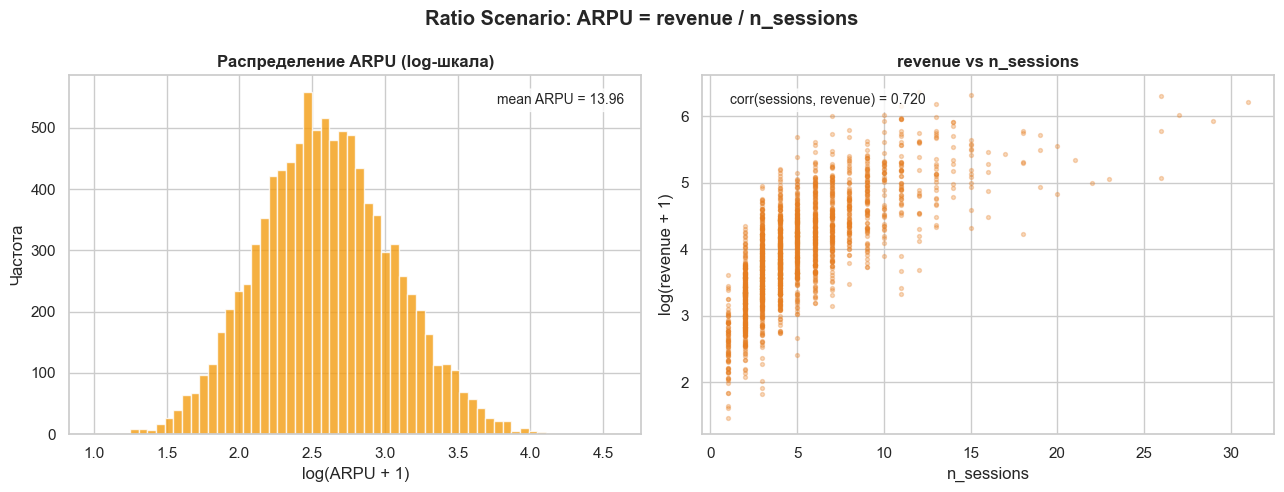

In [ ]:
sc_ratio['arpu'] = sc_ratio['revenue'] / sc_ratio['n_sessions']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(np.log1p(sc_ratio['arpu']), bins=60, color='#f39c12', alpha=0.8)
axes[0].set_title('Распределение ARPU (log-шкала)', fontweight='bold')
axes[0].set_xlabel('log(ARPU + 1)')
axes[0].set_ylabel('Частота')
axes[0].text(0.97, 0.95, f'mean ARPU = {sc_ratio["arpu"].mean():.2f}',
             transform=axes[0].transAxes, ha='right', va='top', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

sample_r = sc_ratio.sample(2000, random_state=42)
axes[1].scatter(sample_r['n_sessions'], np.log1p(sample_r['revenue']),
                alpha=0.3, s=8, color='#e67e22')
axes[1].set_title('revenue vs n_sessions', fontweight='bold')
axes[1].set_xlabel('n_sessions')
axes[1].set_ylabel('log(revenue + 1)')
rho_r = sc_ratio['n_sessions'].corr(sc_ratio['revenue'])
axes[1].text(0.05, 0.95, f'corr(sessions, revenue) = {rho_r:.3f}',
             transform=axes[1].transAxes, va='top', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Ratio Scenario: ARPU = revenue / n_sessions', fontweight='bold')
plt.tight_layout()
plt.show()


### 2.5 Сводная таблица — ключевые характеристики сценариев

In [ ]:
rows = []
for df_s, name, pre_col in [
    (sc_ecomm,  'E-commerce (rho≈0.46)',    'pre_revenue'),
    (sc_lowcor, 'Low Correlation (rho≈0.17)', 'pre_revenue'),
    (sc_ratio,  'Ratio Metric',              None),
    (sc_seg,    'Segmented',                 None),
]:
    rev = df_s['revenue']
    skew_val = float(((rev - rev.mean())**3).mean() / rev.std()**3)
    kurt_val = float(((rev - rev.mean())**4).mean() / rev.std()**4) - 3
    rho_val  = df_s[pre_col].corr(rev) if pre_col else float('nan')

    x_pos = rev[rev > 0].values
    x_min = float(np.quantile(x_pos, 0.90))
    tail  = x_pos[x_pos > x_min]
    hill  = 1/np.mean(np.log(tail/x_min)) if len(tail) > 2 and x_min > 0 else float('nan')

    rows.append({
        'Сценарий':     name,
        'Mean':         round(rev.mean(), 0),
        'Std':          round(rev.std(), 0),
        'Skewness':     round(skew_val, 2),
        'Kurtosis':     round(kurt_val, 1),
        'Hill α':       round(hill, 2),
        'ρ pre/post':   round(rho_val, 3) if not (rho_val != rho_val) else '—',
    })

print(pd.DataFrame(rows).to_string(index=False))


                  Сценарий  Mean   Std  Skewness  Kurtosis  Hill α ρ pre/post
     E-commerce (rho≈0.46) 577.0 558.0      3.37      21.9    2.58      0.459
Low Correlation (rho≈0.17) 579.0 548.0      2.98      16.7    2.67      0.173
              Ratio Metric  75.0  70.0      3.75      29.6    2.67          —
                 Segmented 662.0 793.0      2.98      18.0    2.77          —
